# **PIPELINE ĐẦU TIÊN CỦA BỐ CATBOOST**

**IMPORT**

In [3]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import optuna
import warnings
import os
from huggingface_hub import HfApi, hf_hub_download
warnings.filterwarnings("ignore")

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("CatBoost_FE")
secret_value_1 = user_secrets.get_secret("LightBGM_optuna")

REPO_ID_CatBoost = "thtdung040209020945/CatBoost_FE"
DB_FILE_CatBoost = "catboost_study_FE.db"

api_CatBoost = HfApi(token = secret_value_0)
api_CatBoost.create_repo(repo_id="CatBoost_FE", repo_type = "dataset", private = True)

REPO_ID_LightGBM = "thtdung040209020945/LightGBM"
DB_FILE_LightGBM = "lightgbm_study.db"

api_LightGBM = HfApi(token = secret_value_1)
api_LightGBM.create_repo(repo_id="LightGBM_FE", repo_type = "dataset", private = True)


HfHubHTTPError: Client error '409 Conflict' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-69c73b18-3b50660f0ffd77f2177ddc8f;030232c3-9a64-4c4c-8798-5bc9ff666942)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/409

You already created this dataset repo: thtdung040209020945/CatBoost_FE

**DATA PREPROCESSING**# 

In [12]:
train = pd.read_csv('/kaggle/input/competitions/2026-ptnk-ai-predicting-heart-disease/train.csv')
test = pd.read_csv('/kaggle/input/competitions/2026-ptnk-ai-predicting-heart-disease/test.csv')
train['Heart Disease'] = train['Heart Disease'].map({'Presence': 1, 'Absence': 0})

TARGET = 'Heart Disease'
features = [col for col in train.columns if col not in ['id', TARGET]]


cat_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
                'Exercise angina', 'Slope of ST', 'Thallium']

for col in cat_features:
    train[col] = train[col].astype(str)
    test[col] = test[col].astype(str)

**FEATURE ENGINEERING**

In [13]:
def feature_engineering(df):
    df_out = df.copy()

    # Rate Pressure Product --> khối lượng công việc mà tim đang phải gánh
    df_out['RPP'] = df_out['BP'] * df_out['Max HR']
    # Chỉ số nhịp tim tối đa thâm hụt --> Nếu Max HR thực tế < mức này quá nhiều --> Tim yếu 
    df_out['Max_HR_Deficit'] = (220 - df_out['Age']) - df_out['Max HR']

    # Huyết áp và cholesterol tăng theo tuổi --> nếu người nhỏ mà huyết áo / cholesterol cao giống người lớn tuổi thì nguy hiểm hơn
    df_out['BP_Age_Ratio'] = df_out['BP'] / (df_out['Age'] + 1e-5)
    df_out['Chol_Age_Ratio'] = df_out['Cholesterol'] / (df_out['Age'] + 1e-5)
    
    # Tổng Rủi ro tổng hợp (Severity Score)
    df_out['Severity_Score'] = (
        (df_out['FBS over 120'] == 1).astype(int) +
        (df_out['Exercise angina'] == 1).astype(int) +
        (df_out['ST depression'] > 1.0).astype(int) +
        (df_out['Number of vessels fluro'] > 0).astype(int)
    )
    
    # GBDT khó nhận diện tích/thương, ta tạo sẵn cho nó
    df_out['ST_mul_Slope'] = df_out['ST depression'] * df_out['Slope of ST'].astype(float)
    
    return df_out

train = feature_engineering(train)
test = feature_engineering(test)

features = [col for col in train.columns if col not in ['id', TARGET]]

**OPTUNA**

In [4]:
def load_existing_study_db_for_CatBoost():
    if os.path.exists(DB_FILE_CatBoost):
        os.remove(DB_FILE_CatBoost)
    try: 
        print(f"🔄 Đang kiểm tra Database cũ từ Hugging Face...")
        hf_hub_download(
            repo_id=REPO_ID_CatBoost,
            filename=DB_FILE_CatBoost,
            repo_type="dataset",
            local_dir=".",
            token=secret_value_0
        )
        print("✅ Đã tìm thấy và tải Database cũ. Sẽ RESUME quá trình tuning.")
    except Exception as e:
        print("⚠️ Không tìm thấy file DB trên Cloud. Sẽ tạo Database mới từ đầu.")

In [5]:
def save_study_callback_for_CatBoost(study, trial): # Callback tự động upload file .db lên HF sau mỗi Trial
    try:
        print(f"☁️ Đang đồng bộ trạng thái sau Trial {trial.number} lên HF...")
        api.upload_file(
            path_or_fileobj=DB_FILE_CatBoost,
            path_in_repo=DB_FILE_CatBoost,
            repo_id=REPO_ID_CatBoost,
            repo_type="dataset"
        )
        print("✅ Đã lưu tiến độ an toàn!")
    except Exception as e:
        print(f"❌ Lỗi khi upload backup: {e}")

In [14]:
print(features)

['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'RPP', 'Max_HR_Deficit', 'BP_Age_Ratio', 'Chol_Age_Ratio', 'Severity_Score', 'ST_mul_Slope']


In [8]:
def objective(trial):
    param = {
        "iterations": 1000, 
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        
        # CHỈNH SỬA: Giới hạn độ sâu cây để tăng tính tổng quát hóa
        "depth": trial.suggest_int("depth", 3, 6), 
        
        # CHỈNH SỬA: Tăng cường L2 Regularization
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 3.0, 20.0, log=True), 
        
        # CHỈNH SỬA: Thêm độ ngẫu nhiên mạnh hơn
        "random_strength": trial.suggest_float("random_strength", 0.1, 10.0, log=True), 
        
        "border_count": trial.suggest_categorical("border_count", [32, 64, 128, 254]),
        "eval_metric": "AUC",
        "random_seed": 42,
        "verbose": False,
        "task_type": "GPU"
    }
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(train[features], train[TARGET])):
        X_tr, y_tr = train.iloc[train_idx][features], train.iloc[train_idx][TARGET]
        X_va, y_va = train.iloc[valid_idx][features], train.iloc[valid_idx][TARGET]

        model = CatBoostClassifier(**param, cat_features=cat_features)
        
        model.fit(
            X_tr, y_tr,
            eval_set=(X_va, y_va),
            early_stopping_rounds=50, # Ngừng sớm nếu AUC không tăng sau 50 vòng
            use_best_model=True
        )

        preds = model.predict_proba(X_va)[:, 1]
        auc = roc_auc_score(y_va, preds)
        cv_scores.append(auc)

    return np.mean(cv_scores)


load_existing_study_db_for_CatBoost()
storage_name = f"sqlite:///{DB_FILE_CatBoost}"

study = optuna.create_study(
    direction="maximize", # Mục tiêu là tối đa hóa ROC AUC
    study_name="catboost_heart_disease_opt", 
    storage=storage_name,
    load_if_exists=True # Cực kỳ quan trọng để resume
)

TOTAL_TRIALS = 50 
current_trials = len(study.trials)
print(f"📊 Trạng thái hiện tại: Đã chạy xong {current_trials} trials.")

remaining_trials = TOTAL_TRIALS - current_trials

if remaining_trials > 0:
    print(f"🚀 Bắt đầu chạy tiếp {remaining_trials} trials còn lại...")
    # Gắn hàm callback upload vào đây
    study.optimize(objective, n_trials=remaining_trials, callbacks=[save_study_callback_for_CatBoost])
else:
    print("🎉 Đã hoàn thành đủ số lượng Trials mục tiêu!")

# --- 4. IN KẾT QUẢ ---
print("\n" + "="*40)
print("🏆 KẾT QUẢ TỐI ƯU NHẤT")
print("="*40)
try:
    print(f"Best Trial AUC: {study.best_value:.5f}")
    print("Best Parameters:")
    for key, value in study.best_params.items():
        print(f"    {key}: {value}")
except ValueError:
    print("Chưa có Trial nào hoàn thành thành công.")

🔄 Đang kiểm tra Database cũ từ Hugging Face...


catboost_study_FE.db:   0%|          | 0.00/115k [00:00<?, ?B/s]

[I 2026-03-27 14:06:14,308] Using an existing study with name 'catboost_heart_disease_opt' instead of creating a new one.


✅ Đã tìm thấy và tải Database cũ. Sẽ RESUME quá trình tuning.
📊 Trạng thái hiện tại: Đã chạy xong 2 trials.
🚀 Bắt đầu chạy tiếp 48 trials còn lại...


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-03-27 14:08:12,915] Trial 2 finished with value: 0.9549129395876153 and parameters: {'learning_rate': 0.026237394062691304, 'depth': 4, 'l2_leaf_reg': 3.6288566535131306, 'random_strength': 0.18866613298223434, 'border_count': 254}. Best is trial 2 with value: 0.9549129395876153.


...

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-03-27 15:50:15,281] Trial 49 finished with value: 0.9552179903455059 and parameters: {'learning_rate': 0.04188679978720032, 'depth': 5, 'l2_leaf_reg': 3.328821616066381, 'random_strength': 0.20393357537483886, 'border_count': 254}. Best is trial 37 with value: 0.9553434985282369.


☁️ Đang đồng bộ trạng thái sau Trial 49 lên HF...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Đã lưu tiến độ an toàn!

🏆 KẾT QUẢ TỐI ƯU NHẤT
Best Trial AUC: 0.95534
Best Parameters:
    learning_rate: 0.09861319316170802
    depth: 4
    l2_leaf_reg: 3.0148217827677954
    random_strength: 0.19233554255805727
    border_count: 254


**STRATIFIED K-FOLD CROSS VALIDATION**

In [17]:
print(train.columns)

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease',
       'RPP', 'Severity_Score', 'ST_mul_Slope'],
      dtype='object')


In [18]:
features = [col for col in train.columns if col not in ['id', TARGET]]
cat_features = ['Sex', 'Chest pain type', 'EKG results', 'Exercise angina', 'Slope of ST', 'Thallium']


N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

feature_importances = np.zeros(len(features))

print("Bắt đầu huấn luyện...")
for fold, (train_idx, valid_idx) in enumerate(skf.split(train[features], train[TARGET])):
    X_train, y_train = train.iloc[train_idx][features], train.iloc[train_idx][TARGET]
    X_valid, y_valid = train.iloc[valid_idx][features], train.iloc[valid_idx][TARGET]

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.09861319316170802,
        depth=4,
        l2_leaf_reg=3.0148217827677954,
        random_strength=0.19233554255805727,
        border_count=254,
        eval_metric='AUC',
        random_seed=42,
        cat_features=cat_features,
        verbose=100
    )
    
    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=100,
        use_best_model=True
    )
    
    oof_preds[valid_idx] = model.predict_proba(X_valid)[:, 1]
    
    test_preds += model.predict_proba(test[features])[:, 1] / N_SPLITS
    
    fold_auc = roc_auc_score(y_valid, oof_preds[valid_idx])
    print(f"Fold {fold+1} AUC: {fold_auc:.4f}\n")
    
    feature_importances += model.get_feature_importance() / 5


Bắt đầu huấn luyện...
0:	test: 0.9128434	best: 0.9128434 (0)	total: 368ms	remaining: 6m 7s
100:	test: 0.9546063	best: 0.9546063 (100)	total: 22.1s	remaining: 3m 16s
200:	test: 0.9551372	best: 0.9551372 (200)	total: 45.1s	remaining: 2m 59s
300:	test: 0.9554598	best: 0.9554598 (300)	total: 1m 7s	remaining: 2m 36s
400:	test: 0.9556025	best: 0.9556034 (397)	total: 1m 30s	remaining: 2m 14s
500:	test: 0.9557196	best: 0.9557211 (497)	total: 1m 53s	remaining: 1m 52s
600:	test: 0.9557669	best: 0.9557669 (600)	total: 2m 15s	remaining: 1m 30s
700:	test: 0.9558023	best: 0.9558034 (697)	total: 2m 38s	remaining: 1m 7s
800:	test: 0.9558323	best: 0.9558323 (800)	total: 3m 1s	remaining: 45.2s
900:	test: 0.9558565	best: 0.9558591 (884)	total: 3m 25s	remaining: 22.5s
999:	test: 0.9558655	best: 0.9558668 (989)	total: 3m 48s	remaining: 0us

bestTest = 0.9558668013
bestIteration = 989

Shrink model to first 990 iterations.
Fold 1 AUC: 0.9559

0:	test: 0.9107179	best: 0.9107179 (0)	total: 308ms	remaining: 5m

**Feature Importance**

--- TOP 5 ĐẶC TRƯNG MẠNH NHẤT ---
           Feature  Importance
0         Thallium   20.445676
1           Max HR   19.804149
2  Chest pain type   16.192752
3   Severity_Score    7.201789
4  Exercise angina    7.071672

--- TOP 5 ĐẶC TRƯNG YẾU NHẤT ---
          Feature  Importance
10    Cholesterol    1.574249
11    EKG results    1.172345
12  ST depression    1.087335
13             BP    0.579100
14            RPP    0.337292


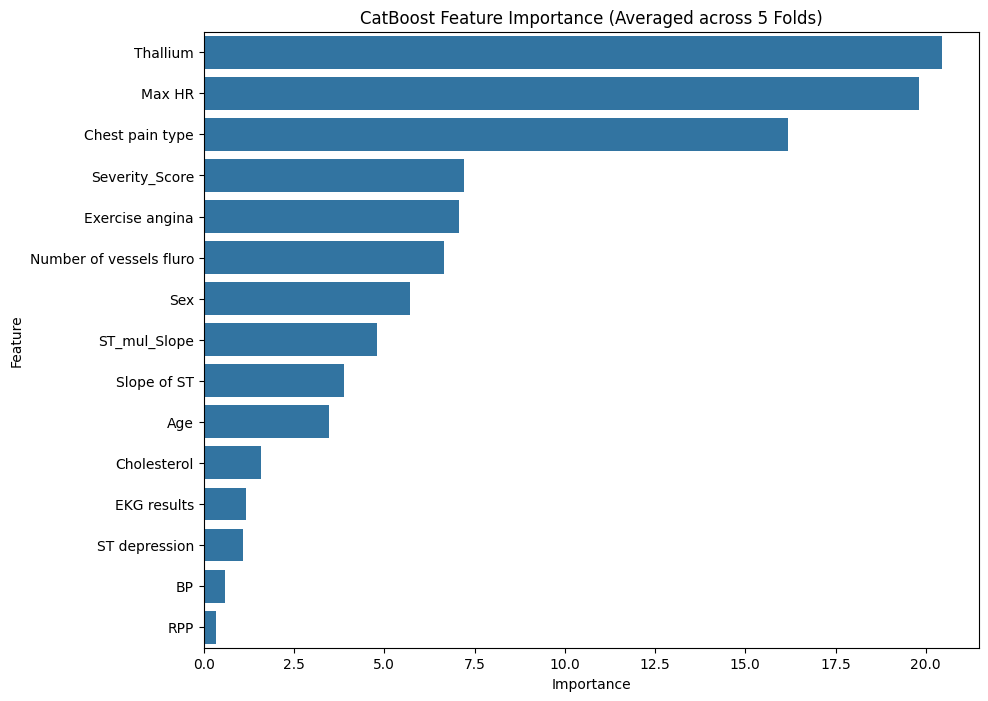

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- TOP 5 ĐẶC TRƯNG MẠNH NHẤT ---")
print(fi_df.head(5))
print("\n--- TOP 5 ĐẶC TRƯNG YẾU NHẤT ---")
print(fi_df.tail(5))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df)
plt.title('CatBoost Feature Importance (Averaged across 5 Folds)')
plt.show()

**OUTPUT SUBMISSION**

In [21]:
cv_auc = roc_auc_score(train[TARGET], oof_preds)
print(f"Tổng thể Cross Validation AUC: {cv_auc:.4f}")

submission = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': test_preds
})

submission.to_csv('submission.csv', index=False)
print("Đã tạo file submission.csv thành công!")

Tổng thể Cross Validation AUC: 0.9555
Đã tạo file submission.csv thành công!


# **TẠO PIPELINE MỚI VỚI LIGHTGBM**

Với LightGBM và XGBoost thì phải ép kiểu categorical features thành .astype('category')

In [ ]:
train = pd.read_csv("/kaggle/input/competitions/2026-ptnk-ai-predicting-heart-disease/train.csv")
test = pd.read_csv("/kaggle/input/competitions/2026-ptnk-ai-predicting-heart-disease/test.csv")
cat_features = ["Sex", "Chest pain type", "FBS over 120", "EKG results", "Exercise angina", "Slope of ST", "Thalium"]

for col in cat_features:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

train = feature_engineering(train)
test = feature_engineering(test)


**OPTUNA**

In [ ]:
def save_study_callback_for_LightGBM(study, trial): # Callback tự động upload file .db lên HF sau mỗi Trial
    try:
        print(f"☁️ Đang đồng bộ trạng thái sau Trial {trial.number} lên HF...")
        api.upload_file(
            path_or_fileobj=DB_FILE_LightGBM,
            path_in_repo=DB_FILE_LightGBM,
            repo_id=REPO_ID_LightGBM,
            repo_type="dataset"
        )
        print("✅ Đã lưu tiến độ an toàn!")
    except Exception as e:
        print(f"❌ Lỗi khi upload backup: {e}")

In [ ]:
def load_existing_study_db_for_CatBoost():
    if os.path.exists(DB_FILE_LightGBM):
        os.remove(DB_FILE_LightGBM)
    try: 
        print(f"🔄 Đang kiểm tra Database cũ từ Hugging Face...")
        hf_hub_download(
            repo_id=REPO_ID_LightGBM,
            filename=DB_FILE_LightGBM,
            repo_type="dataset",
            local_dir=".",
            token=secret_value_1
        )
        print("✅ Đã tìm thấy và tải Database cũ. Sẽ RESUME quá trình tuning.")
    except Exception as e:
        print("⚠️ Không tìm thấy file DB trên Cloud. Sẽ tạo Database mới từ đầu.")

In [ ]:
def objective_LightGBM(trial):
    param = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63), # Đừng set quá 64
        "max_depth": trial.suggest_int("max_depth", 3, 7), # Khóa chặt chiều sâu
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150), # Số sample tối thiểu trong 1 lá
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "verbose": -1, # Tắt log rác
        "random_state": 42,
        "task_type": "GPU"
    }
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(train[features], train[TARGET])):
        X_tr, y_tr = train.iloc[train_idx][features], train.iloc[train_idx][TARGET]
        X_va, y_va = train.iloc[valid_idx][features], train.iloc[valid_idx][TARGET]

        model = lgb.LGBMClassifier(**param)
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks = [lgb.early_stopping(50, verbose=False}], # Ngừng sớm nếu AUC không tăng sau 50 vòng
            use_best_model=True
        )

        preds = model.predict_proba(X_va)[:, 1]
        auc = roc_auc_score(y_va, preds)
        cv_scores.append(auc)

    return np.mean(cv_scores)


load_existing_study_db_for_LightGBM()
storage_name = f"sqlite:///{DB_FILE_LightGBM}"

study = optuna.create_study(
    direction="maximize", # Mục tiêu là tối đa hóa ROC AUC
    study_name="LGBM_heart_disease_opt", 
    storage=storage_name,
    load_if_exists=True # Cực kỳ quan trọng để resume
)

TOTAL_TRIALS = 50 
current_trials = len(study.trials)
print(f"📊 Trạng thái hiện tại: Đã chạy xong {current_trials} trials.")

remaining_trials = TOTAL_TRIALS - current_trials

if remaining_trials > 0:
    print(f"🚀 Bắt đầu chạy tiếp {remaining_trials} trials còn lại...")
    # Gắn hàm callback upload vào đây
    study.optimize(objective_LightGBM, n_trials=remaining_trials, callbacks=[save_study_callback_for_LightGBM])
else:
    print("🎉 Đã hoàn thành đủ số lượng Trials mục tiêu!")

# --- 4. IN KẾT QUẢ ---
print("\n" + "="*40)
print("🏆 KẾT QUẢ TỐI ƯU NHẤT")
print("="*40)
try:
    print(f"Best Trial AUC: {study.best_value:.5f}")
    print("Best Parameters:")
    for key, value in study.best_params.items():
        print(f"    {key}: {value}")
except ValueError:
    print("Chưa có Trial nào hoàn thành thành công.")